In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [2]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

speed_threshold = 3

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled


In [3]:
# Find and load all theta_amp_state_speed*.npz files
pattern = os.path.join(data_folder, 'CKII**', f'theta_amp_state_speed{speed_threshold}.npz')
npz_files = glob.glob(pattern, recursive=True)
print(f'Found {len(npz_files)} theta_amp_state files:')
for f in npz_files:
    print(f'  {f}')

# Pool data from all datasets
theta_run_all = []
theta_rest_all = []

for npz_path in npz_files:
    data = np.load(npz_path)
    theta_run_all.append(data['theta_run'])
    theta_rest_all.append(data['theta_rest'])
    print(f'Loaded {os.path.basename(os.path.dirname(npz_path))}: {len(data["theta_run"])} cells')

# Concatenate all data
theta_run = np.concatenate(theta_run_all) if theta_run_all else np.array([])
theta_rest = np.concatenate(theta_rest_all) if theta_rest_all else np.array([])

print(f'\nTotal pooled cells: {len(theta_run)}')

Found 3 theta_amp_state files:
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce21_PR_20250806/theta_amp_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce45_PX_20260118/theta_amp_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/theta_amp_state_speed3.npz
Loaded CKII_pAce21_PR_20250806: 9 cells
Loaded CKII_pAce45_PX_20260118: 16 cells
Loaded CKII_pAce38_PX_20251126: 9 cells

Total pooled cells: 34


In [4]:
# Helper functions for statistical tests and plotting

def _paired_test(vals_a, vals_b):
    vals_a = np.asarray(vals_a, dtype=float)
    vals_b = np.asarray(vals_b, dtype=float)
    n_pairs = min(len(vals_a), len(vals_b))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_a = vals_a[:n_pairs]
    paired_b = vals_b[:n_pairs]
    valid = np.isfinite(paired_a) & np.isfinite(paired_b)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_a[valid] - paired_b[valid]
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = stats.ttest_rel(paired_a[valid], paired_b[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = stats.wilcoxon(paired_a[valid], paired_b[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

def _global_ylim(arrays, pad_frac=0.08):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite)
    if not vals:
        return None
    merged = np.concatenate(vals)
    y_min = np.nanmin(merged)
    y_max = np.nanmax(merged)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad

State theta amp (wilcoxon): n=31, stat=106, p=0.00444, shapiro_p=2.12e-05
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/ThetaAmp_state_pooled.svg


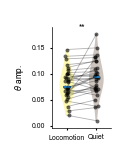

In [5]:
# Plot theta amplitude by behavioral state: Locomotion vs Quiet (Pooled)

panel_w = 1.2
panel_h = 1.5
xlim = (0.5, 2.5)

run_color = "#f9e800ff"
rest_color = "#563c25"

theta_ylim = _global_ylim([theta_run, theta_rest])

fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h), sharex=True, sharey=True)
plot_data = []
for vals in [theta_run, theta_rest]:
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        finite = np.array([np.nan])
    plot_data.append(finite)

parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
for body in parts['bodies']:
    body.set_alpha(0.3)
if len(parts['bodies']) >= 2:
    parts['bodies'][0].set_facecolor(run_color)
    parts['bodies'][1].set_facecolor(rest_color)
    parts['bodies'][0].set_edgecolor('none')
    parts['bodies'][1].set_edgecolor('none')

# Draw paired lines
n_pairs = min(len(theta_run), len(theta_rest))
for i in range(n_pairs):
    if np.isfinite(theta_run[i]) and np.isfinite(theta_rest[i]):
        ax.plot(
            [1, 2],
            [theta_run[i], theta_rest[i]],
            color='black',
            alpha=0.3,
            linewidth=0.6,
        )

# Scatter individual data points
rng = np.random.default_rng(0)
for idx, vals in enumerate([theta_run, theta_rest], start=1):
    finite_mask = np.isfinite(vals)
    if not np.any(finite_mask):
        continue
    jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
    xs = idx + jitter
    ax.scatter(
        xs,
        vals[finite_mask],
        s=8,
        color='black',
        alpha=0.6,
        linewidths=0,
    )

# Statistical test
p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(theta_run, theta_rest)
sig_label = _sig_label(p_val)
if np.isfinite(p_val):
    print(
        f"State theta amp ({test_name}): n={n_valid}, "
        f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
    )
else:
    print(f"State theta amp: n={n_valid} (insufficient valid pairs)")

# Add significance label
if sig_label:
    y_vals = np.concatenate([theta_run[np.isfinite(theta_run)], theta_rest[np.isfinite(theta_rest)]])
    if y_vals.size > 0:
        y_max = np.nanmax(y_vals)
        y_min = np.nanmin(y_vals)
        y_span = y_max - y_min if y_max != y_min else 1.0
        y_off = 0.08 * y_span
        y_star = y_max + y_off
        if theta_ylim is not None:
            y0, y1 = theta_ylim
            y_span_global = y1 - y0 if y1 != y0 else 1.0
            y_star = min(y_star, y1 - 0.05 * y_span_global)
        ax.text(
            1.5,
            y_star,
            sig_label,
            ha='center',
            va='bottom',
            fontsize=6,
            fontname='Arial',
        )

ax.set_xticks([1, 2])
ax.set_xticklabels(['Locomotion', 'Quiet'], fontsize=5, fontname='Arial')
ax.set_ylabel(r'$\theta$ amp.', fontsize=6, fontname='Arial')
ax.tick_params(labelsize=5)
ax.set_xlim(*xlim)
if theta_ylim is not None:
    ax.set_ylim(*theta_ylim)
for label in list(ax.get_yticklabels()):
    label.set_fontname('Arial')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.9])
theta_violin_out_path = os.path.join(
    figure_save_folder,
    f"ThetaAmp_state_pooled.svg",
)
fig.savefig(theta_violin_out_path, dpi=300)
print(f"Saved to {theta_violin_out_path}")
plt.show()

In [6]:
# Print summary statistics
print('\n=== Summary Statistics ===')
print(f'Total pooled cells: {len(theta_run)}')

# Theta amplitude during locomotion
valid_run = theta_run[np.isfinite(theta_run)]
if valid_run.size > 0:
    print(f'\nLocomtion theta amp: mean={np.mean(valid_run):.4f}, '
          f'median={np.median(valid_run):.4f}, std={np.std(valid_run):.4f}, n={len(valid_run)}')

# Theta amplitude during quiet
valid_rest = theta_rest[np.isfinite(theta_rest)]
if valid_rest.size > 0:
    print(f'Quiet theta amp: mean={np.mean(valid_rest):.4f}, '
          f'median={np.median(valid_rest):.4f}, std={np.std(valid_rest):.4f}, n={len(valid_rest)}')

# Difference
valid_both = np.isfinite(theta_run) & np.isfinite(theta_rest)
if np.sum(valid_both) > 0:
    diff = theta_run[valid_both] - theta_rest[valid_both]
    print(f'\nDifference (Locomotion - Quiet): mean={np.mean(diff):.4f}, '
          f'median={np.median(diff):.4f}, std={np.std(diff):.4f}')


=== Summary Statistics ===
Total pooled cells: 34

Locomtion theta amp: mean=0.0804, median=0.0739, std=0.0293, n=31
Quiet theta amp: mean=0.0916, median=0.0937, std=0.0345, n=31

Difference (Locomotion - Quiet): mean=-0.0112, median=-0.0063, std=0.0236
